In [ ]:
def visualize_iou_example(box1, box2, title):
    """Visualize two boxes and their IoU"""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Draw first box (ground truth)
    rect1 = Rectangle((x1_1, y1_1), x2_1-x1_1, y2_1-y1_1,
                     linewidth=3, edgecolor='green', facecolor='green', alpha=0.3,
                     label='Ground Truth')
    ax.add_patch(rect1)
    
    # Draw second box (prediction)
    rect2 = Rectangle((x1_2, y1_2), x2_2-x1_2, y2_2-y1_2,
                     linewidth=3, edgecolor='red', facecolor='red', alpha=0.3,
                     label='Prediction')
    ax.add_patch(rect2)
    
    # Calculate and show intersection if exists
    x1_inter = max(x1_1, x1_2)
    y1_inter = max(y1_1, y1_2)
    x2_inter = min(x2_1, x2_2)
    y2_inter = min(y2_1, y2_2)
    
    if x2_inter > x1_inter and y2_inter > y1_inter:
        rect_inter = Rectangle((x1_inter, y1_inter), x2_inter-x1_inter, y2_inter-y1_inter,
                             linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.6,
                             label='Intersection')
        ax.add_patch(rect_inter)
    
    iou = calculate_iou(box1, box2)
    
    ax.set_xlim(-5, max(x2_1, x2_2) + 5)
    ax.set_ylim(-5, max(y2_1, y2_2) + 5)
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{title}\\nIoU = {iou:.3f}', fontsize=14, fontweight='bold')
    
    # Add interpretation
    if iou >= 0.7:
        interpretation = "🟢 Excellent"
    elif iou >= 0.5:
        interpretation = "🟡 Good"  
    elif iou > 0:
        interpretation = "🟠 Poor"
    else:
        interpretation = "🔴 No overlap"
    
    ax.text(0.02, 0.98, interpretation, transform=ax.transAxes, fontsize=12, 
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Show different IoU scenarios
print("Examples of different IoU values:\\n")

print("1️⃣ HIGH IoU (Excellent detection):")
visualize_iou_example([10, 10, 50, 30], [12, 12, 48, 28], "High IoU")

print("\\n2️⃣ MEDIUM IoU (Okay detection):")
visualize_iou_example([10, 10, 50, 30], [20, 15, 60, 35], "Medium IoU")

print("\\n3️⃣ LOW IoU (Poor detection):")
visualize_iou_example([10, 10, 50, 30], [30, 25, 70, 45], "Low IoU")

print("\\n4️⃣ ZERO IoU (Completely missed):")
visualize_iou_example([10, 10, 30, 30], [50, 50, 70, 70], "No Overlap")

### Visualizing Different IoU Values

Let's see what different IoU values look like visually:

In [ ]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two bounding boxes.
    Args:
        box1, box2: [x1, y1, x2, y2] format
    Returns:
        iou: Intersection over Union value (0 to 1)
    """
    # Extract coordinates
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Calculate intersection rectangle
    x1_inter = max(x1_1, x1_2)  # Left edge of intersection
    y1_inter = max(y1_1, y1_2)  # Top edge of intersection
    x2_inter = min(x2_1, x2_2)  # Right edge of intersection
    y2_inter = min(y2_1, y2_2)  # Bottom edge of intersection
    
    # Check if there's any intersection
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0  # No intersection
    
    # Calculate areas
    intersection_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = area1 + area2 - intersection_area
    
    # Calculate IoU
    iou = intersection_area / union_area if union_area > 0 else 0.0
    
    return iou

# Let's test with a concrete example from our data
gt_box = [10, 10, 50, 30]      # Ground truth car in image_1
pred_box = [12, 12, 48, 28]    # Our prediction for that car

iou = calculate_iou(gt_box, pred_box)
print(f"🔍 EXAMPLE CALCULATION:")
print(f"Ground truth box: {gt_box}")
print(f"Prediction box: {pred_box}")
print(f"IoU: {iou:.3f}")

# Let's show the math step by step
x1_1, y1_1, x2_1, y2_1 = gt_box
x1_2, y1_2, x2_2, y2_2 = pred_box

print(f"\\n📐 STEP-BY-STEP CALCULATION:")
print(f"1. GT box area: ({x2_1}-{x1_1}) × ({y2_1}-{y1_1}) = {(x2_1-x1_1) * (y2_1-y1_1)}")
print(f"2. Pred box area: ({x2_2}-{x1_2}) × ({y2_2}-{y1_2}) = {(x2_2-x1_2) * (y2_2-y1_2)}")

x1_inter = max(x1_1, x1_2)
y1_inter = max(y1_1, y1_2)
x2_inter = min(x2_1, x2_2)
y2_inter = min(y2_1, y2_2)
intersection_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)

print(f"3. Intersection area: ({x2_inter}-{x1_inter}) × ({y2_inter}-{y1_inter}) = {intersection_area}")
union_area = (x2_1-x1_1)*(y2_1-y1_1) + (x2_2-x1_2)*(y2_2-y1_2) - intersection_area
print(f"4. Union area: {(x2_1-x1_1)*(y2_1-y1_1)} + {(x2_2-x1_2)*(y2_2-y1_2)} - {intersection_area} = {union_area}")
print(f"5. IoU: {intersection_area}/{union_area} = {intersection_area/union_area:.3f}")

print(f"\\n✅ This is a GOOD detection because IoU = {iou:.3f} > 0.5")

## Step 2: Understanding IoU (Intersection over Union)

IoU is **the most important concept** in object detection evaluation. It measures how much two bounding boxes overlap.

**Why do we need IoU?**
- A perfect detection doesn't need to have exactly the same coordinates as ground truth
- We need a way to measure "close enough"
- IoU gives us a score from 0 (no overlap) to 1 (perfect overlap)

**Formula:** IoU = (Area of Intersection) / (Area of Union)

In [ ]:
def visualize_image(img_id, ground_truth, predictions, confidence_threshold=0.0):
    """Visualize ground truth and predictions for one image"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Set image bounds (simulating a 100x100 image)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    ax.invert_yaxis()  # Invert y-axis to match image coordinates (0,0 at top-left)
    
    # Draw ground truth boxes in green
    gt_objects = ground_truth[img_id]
    for i, obj in enumerate(gt_objects):
        x1, y1, x2, y2 = obj['bbox']
        width = x2 - x1
        height = y2 - y1
        
        rect = Rectangle((x1, y1), width, height, 
                        linewidth=3, edgecolor='green', facecolor='none', 
                        label='Ground Truth' if i == 0 else """)
        ax.add_patch(rect)
        
        # Add label
        ax.text(x1, y1-2, f"GT: {obj['class']}", 
               bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgreen'),
               fontsize=10, fontweight='bold')
    
    # Draw prediction boxes in red  
    pred_objects = [p for p in predictions[img_id] if p['confidence'] >= confidence_threshold]
    for i, obj in enumerate(pred_objects):
        x1, y1, x2, y2 = obj['bbox']
        width = x2 - x1
        height = y2 - y1
        
        rect = Rectangle((x1, y1), width, height, 
                        linewidth=2, edgecolor='red', facecolor='none', linestyle='--',
                        label='Predictions' if i == 0 else "")
        ax.add_patch(rect)
        
        # Add label
        ax.text(x2, y2+2, f"Pred: {obj['class']}\\n{obj['confidence']:.2f}", 
               bbox=dict(boxstyle="round,pad=0.2", facecolor='lightcoral'),
               fontsize=10)
    
    ax.set_title(f'{img_id.replace("_", " ").title()} - Ground Truth vs Predictions', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    plt.tight_layout()
    plt.show()

# Visualize our two images
print("📸 IMAGE 1:")
visualize_image('image_1', ground_truth, predictions)

print("\\n📸 IMAGE 2:")
visualize_image('image_2', ground_truth, predictions)

### Let's Visualize Our Dataset

Before diving into metrics, let's see what our data looks like.

# Object Detection Metrics: A Step-by-Step Tutorial

Object detection is more complex than image classification because we need to evaluate two things:
1. **Where** are the objects? (localization)
2. **What** are the objects? (classification)

In this tutorial, we'll build understanding step by step using a minimal, realistic example.

## Why This Tutorial is Different

- **Minimal dataset**: Just 2 images, 2 classes to keep things crystal clear
- **Step-by-step**: Each concept builds on the previous one
- **Realistic examples**: Real-world scenarios with mistakes and edge cases
- **Visual explanations**: See exactly what happens at each step

## Setup

Let's import what we need and set up our environment.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import pandas as pd

# Set up plotting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## Step 1: Our Minimal, Realistic Dataset

Let's start with just **2 images** and **2 classes** (car, person) to keep things simple and understandable.

Think of this as a parking lot security camera that needs to detect cars and people.

In [ ]:
# Our simple dataset: 2 images, 2 classes
classes = ['car', 'person']

# Ground truth: what's actually in each image
# Bounding boxes are [x1, y1, x2, y2] where (x1,y1) is top-left, (x2,y2) is bottom-right
ground_truth = {
    'image_1': [
        {'bbox': [10, 10, 50, 30], 'class': 'car'},      # One car
        {'bbox': [60, 20, 80, 60], 'class': 'person'}    # One person
    ],
    'image_2': [
        {'bbox': [15, 15, 45, 35], 'class': 'car'}       # One car
    ]
}

# Model predictions: what our model thinks it sees
# Note: Real models make mistakes!
predictions = {
    'image_1': [
        {'bbox': [12, 12, 48, 28], 'class': 'car', 'confidence': 0.9},     # Good car detection
        {'bbox': [65, 25, 85, 65], 'class': 'person', 'confidence': 0.8},  # Good person detection
        {'bbox': [20, 70, 40, 90], 'class': 'car', 'confidence': 0.3}      # False detection (no car here!)
    ],
    'image_2': [
        {'bbox': [10, 10, 40, 30], 'class': 'car', 'confidence': 0.85}     # Good car detection
    ]
}

print("🎯 GROUND TRUTH (what's actually there):")
for img_id, objects in ground_truth.items():
    print(f"  {img_id}: {len(objects)} objects")
    for obj in objects:
        print(f"    - {obj['class']} at {obj['bbox']}")

print("\n🤖 MODEL PREDICTIONS (what our model thinks):")
for img_id, objects in predictions.items():
    print(f"  {img_id}: {len(objects)} predictions")
    for obj in objects:
        print(f"    - {obj['class']} at {obj['bbox']} (confidence: {obj['confidence']:.1f})")

print("\n💡 Notice: The model made 1 extra prediction in image_1 - this will be important later!")

### Visualizing IoU

Let's create a function to visualize how IoU works with different overlaps.

Example 1: Good Detection (IoU > 0.5)


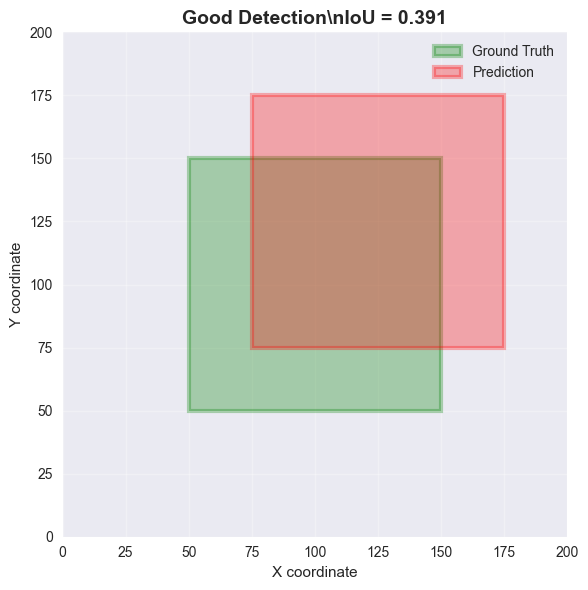

In [3]:
def visualize_iou(box1, box2, title=""):
    """Visualize two bounding boxes and their IoU"""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Draw ground truth box (green)
    rect1 = Rectangle((box1[0], box1[1]), box1[2]-box1[0], box1[3]-box1[1], 
                     linewidth=3, edgecolor='green', facecolor='green', alpha=0.3, label='Ground Truth')
    ax.add_patch(rect1)
    
    # Draw prediction box (red)
    rect2 = Rectangle((box2[0], box2[1]), box2[2]-box2[0], box2[3]-box2[1], 
                     linewidth=3, edgecolor='red', facecolor='red', alpha=0.3, label='Prediction')
    ax.add_patch(rect2)
    
    # Calculate and display IoU
    iou = calculate_iou(box1, box2)
    
    # Set plot properties
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{title}\\nIoU = {iou:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    
    plt.tight_layout()
    plt.show()

# Example 1: Good overlap (IoU > 0.5)
print("Example 1: Good Detection (IoU > 0.5)")
visualize_iou([50, 50, 150, 150], [75, 75, 175, 175], "Good Detection")

Example 2: Poor Detection (IoU < 0.5)


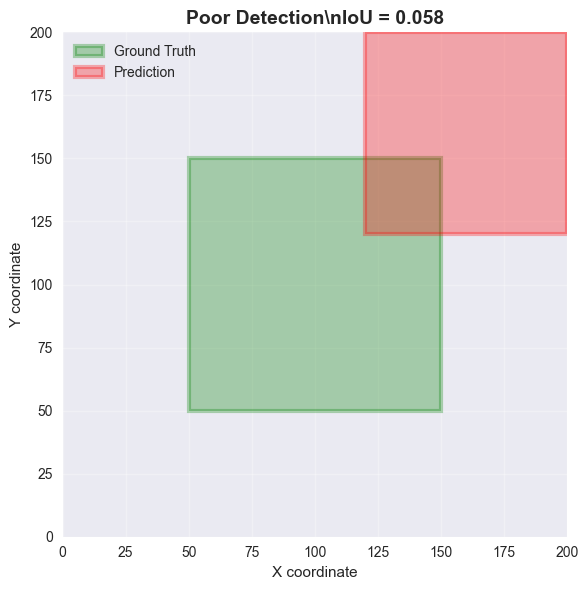

Example 3: No Detection (IoU = 0)


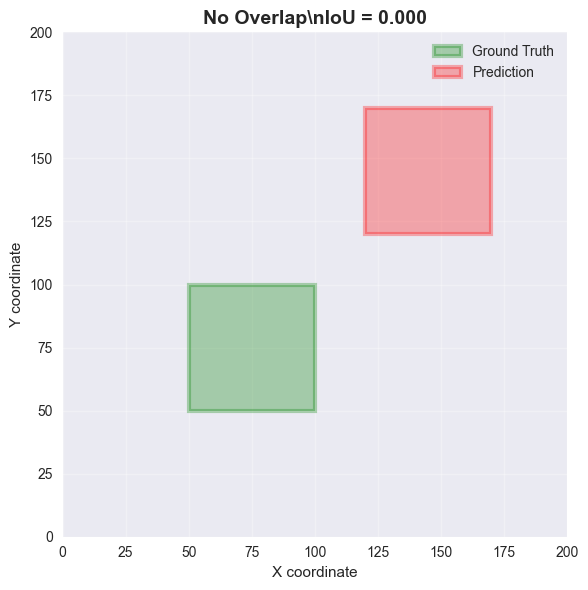

In [4]:
# Example 2: Poor overlap (IoU < 0.5)
print("Example 2: Poor Detection (IoU < 0.5)")
visualize_iou([50, 50, 150, 150], [120, 120, 200, 200], "Poor Detection")

# Example 3: No overlap (IoU = 0)
print("Example 3: No Detection (IoU = 0)")
visualize_iou([50, 50, 100, 100], [120, 120, 170, 170], "No Overlap")

## 2. Creating a Simple 3-Class Detection Dataset

Let's create a synthetic dataset with 3 classes: **car**, **person**, and **bike**. We'll simulate both ground truth annotations and model predictions.

In [5]:
# Define our classes
classes = ['car', 'person', 'bike']
class_to_id = {cls: i for i, cls in enumerate(classes)}
id_to_class = {i: cls for i, cls in enumerate(classes)}

print("Class mapping:")
for cls, id in class_to_id.items():
    print(f"{cls}: {id}")

# Create ground truth data for 5 images
ground_truth = {
    'image_1': [
        {'bbox': [20, 30, 120, 80], 'class': 'car', 'class_id': 0},
        {'bbox': [150, 50, 180, 120], 'class': 'person', 'class_id': 1}
    ],
    'image_2': [
        {'bbox': [10, 10, 90, 60], 'class': 'bike', 'class_id': 2},
        {'bbox': [100, 40, 200, 90], 'class': 'car', 'class_id': 0},
        {'bbox': [220, 30, 250, 100], 'class': 'person', 'class_id': 1}
    ],
    'image_3': [
        {'bbox': [50, 50, 150, 100], 'class': 'car', 'class_id': 0}
    ],
    'image_4': [
        {'bbox': [30, 20, 60, 80], 'class': 'person', 'class_id': 1},
        {'bbox': [80, 30, 110, 70], 'class': 'person', 'class_id': 1},
        {'bbox': [130, 40, 180, 90], 'class': 'bike', 'class_id': 2}
    ],
    'image_5': [
        {'bbox': [40, 40, 140, 90], 'class': 'car', 'class_id': 0},
        {'bbox': [160, 60, 190, 130], 'class': 'person', 'class_id': 1},
        {'bbox': [200, 20, 230, 60], 'class': 'bike', 'class_id': 2}
    ]
}

print(f"\\nGround truth created for {len(ground_truth)} images")
for img_id, annotations in ground_truth.items():
    print(f"{img_id}: {len(annotations)} objects")

Class mapping:
car: 0
person: 1
bike: 2
\nGround truth created for 5 images
image_1: 2 objects
image_2: 3 objects
image_3: 1 objects
image_4: 3 objects
image_5: 3 objects


In [6]:
# Create model predictions (with confidence scores)
# Note: Real models make mistakes - some predictions may be wrong or miss objects
predictions = {
    'image_1': [
        {'bbox': [25, 35, 115, 85], 'class': 'car', 'class_id': 0, 'confidence': 0.9},
        {'bbox': [145, 45, 185, 115], 'class': 'person', 'class_id': 1, 'confidence': 0.8},
        {'bbox': [60, 10, 90, 40], 'class': 'bike', 'class_id': 2, 'confidence': 0.3}  # False positive
    ],
    'image_2': [
        {'bbox': [15, 15, 85, 65], 'class': 'bike', 'class_id': 2, 'confidence': 0.85},
        {'bbox': [105, 45, 195, 95], 'class': 'car', 'class_id': 0, 'confidence': 0.92},
        # Missing the person detection (False Negative)
    ],
    'image_3': [
        {'bbox': [45, 55, 145, 105], 'class': 'car', 'class_id': 0, 'confidence': 0.88}
    ],
    'image_4': [
        {'bbox': [35, 25, 65, 75], 'class': 'person', 'class_id': 1, 'confidence': 0.75},
        {'bbox': [85, 35, 115, 75], 'class': 'person', 'class_id': 1, 'confidence': 0.82},
        {'bbox': [135, 45, 175, 95], 'class': 'bike', 'class_id': 2, 'confidence': 0.77},
        {'bbox': [200, 200, 230, 240], 'class': 'car', 'class_id': 0, 'confidence': 0.4}  # False positive
    ],
    'image_5': [
        {'bbox': [42, 42, 138, 88], 'class': 'car', 'class_id': 0, 'confidence': 0.91},
        {'bbox': [158, 58, 192, 128], 'class': 'person', 'class_id': 1, 'confidence': 0.86},
        # Missing the bike detection (False Negative)
        {'bbox': [10, 10, 40, 50], 'class': 'person', 'class_id': 1, 'confidence': 0.35}  # False positive
    ]
}

print("Model predictions created")
for img_id, preds in predictions.items():
    print(f"{img_id}: {len(preds)} predictions")

Model predictions created
image_1: 3 predictions
image_2: 2 predictions
image_3: 1 predictions
image_4: 4 predictions
image_5: 3 predictions


## 3. Understanding Confidence Scores and Thresholds

**Confidence scores** indicate how certain the model is about each prediction. Higher scores mean more confidence.

**Key concepts:**
- **Confidence threshold**: We only consider predictions above this threshold
- **True Positive (TP)**: Correct detection (IoU ≥ threshold AND correct class)
- **False Positive (FP)**: Incorrect detection (IoU < threshold OR wrong class)
- **False Negative (FN)**: Missed ground truth object

In [7]:
def evaluate_predictions(ground_truth, predictions, confidence_threshold=0.5, iou_threshold=0.5):
    """
    Evaluate predictions against ground truth.
    
    Returns:
        results: Dict with TP, FP, FN counts per class and overall
    """
    results = {
        'per_class': {cls: {'TP': 0, 'FP': 0, 'FN': 0} for cls in classes},
        'overall': {'TP': 0, 'FP': 0, 'FN': 0}
    }
    
    for img_id in ground_truth.keys():
        gt_boxes = ground_truth[img_id]
        pred_boxes = [p for p in predictions.get(img_id, []) if p['confidence'] >= confidence_threshold]
        
        # Track which ground truth boxes have been matched
        gt_matched = [False] * len(gt_boxes)
        
        # Process each prediction
        for pred in pred_boxes:
            best_iou = 0
            best_gt_idx = -1
            
            # Find best matching ground truth box
            for gt_idx, gt in enumerate(gt_boxes):
                if gt['class_id'] == pred['class_id']:  # Same class
                    iou = calculate_iou(pred['bbox'], gt['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_idx
            
            # Determine if this is TP or FP
            if best_iou >= iou_threshold and not gt_matched[best_gt_idx]:
                # True Positive
                results['per_class'][pred['class']]['TP'] += 1
                results['overall']['TP'] += 1
                gt_matched[best_gt_idx] = True
            else:
                # False Positive
                results['per_class'][pred['class']]['FP'] += 1
                results['overall']['FP'] += 1
        
        # Count False Negatives (unmatched ground truth boxes)
        for gt_idx, matched in enumerate(gt_matched):
            if not matched:
                gt_class = gt_boxes[gt_idx]['class']
                results['per_class'][gt_class]['FN'] += 1
                results['overall']['FN'] += 1
    
    return results

# Evaluate with different confidence thresholds
thresholds = [0.3, 0.5, 0.7, 0.9]
print("Evaluation Results at Different Confidence Thresholds:")
print("=" * 60)

for conf_thresh in thresholds:
    results = evaluate_predictions(ground_truth, predictions, confidence_threshold=conf_thresh)
    print(f"\\nConfidence Threshold: {conf_thresh}")
    print(f"Overall - TP: {results['overall']['TP']}, FP: {results['overall']['FP']}, FN: {results['overall']['FN']}")

Evaluation Results at Different Confidence Thresholds:
\nConfidence Threshold: 0.3
Overall - TP: 10, FP: 3, FN: 2
\nConfidence Threshold: 0.5
Overall - TP: 10, FP: 0, FN: 2
\nConfidence Threshold: 0.7
Overall - TP: 10, FP: 0, FN: 2
\nConfidence Threshold: 0.9
Overall - TP: 3, FP: 0, FN: 9


## 4. Precision and Recall

**Precision** and **Recall** are fundamental metrics for understanding model performance:

- **Precision = TP / (TP + FP)** → "Of all predictions, how many were correct?"
- **Recall = TP / (TP + FN)** → "Of all ground truth objects, how many did we detect?"

**Trade-off:** Higher confidence threshold → Higher precision, Lower recall

In [8]:
def calculate_precision_recall(tp, fp, fn):
    """Calculate precision and recall from TP, FP, FN counts"""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall

# Calculate precision-recall for different confidence thresholds
conf_thresholds = np.arange(0.1, 1.0, 0.1)
precision_recall_data = []

print("Precision-Recall Analysis:")
print("=" * 50)
print(f"{'Confidence':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 50)

for conf_thresh in conf_thresholds:
    results = evaluate_predictions(ground_truth, predictions, confidence_threshold=conf_thresh)
    
    tp = results['overall']['TP']
    fp = results['overall']['FP']
    fn = results['overall']['FN']
    
    precision, recall = calculate_precision_recall(tp, fp, fn)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    precision_recall_data.append({
        'confidence': conf_thresh,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    })
    
    print(f"{conf_thresh:<12.1f} {precision:<12.3f} {recall:<12.3f} {f1_score:<12.3f}")

# Convert to DataFrame for easier manipulation
pr_df = pd.DataFrame(precision_recall_data)

Precision-Recall Analysis:
Confidence   Precision    Recall       F1-Score    
--------------------------------------------------
0.1          0.769        0.833        0.800       
0.2          0.769        0.833        0.800       
0.3          0.833        0.833        0.833       
0.4          0.909        0.833        0.870       
0.5          1.000        0.833        0.909       
0.6          1.000        0.833        0.909       
0.7          1.000        0.833        0.909       
0.8          1.000        0.667        0.800       
0.9          1.000        0.250        0.400       


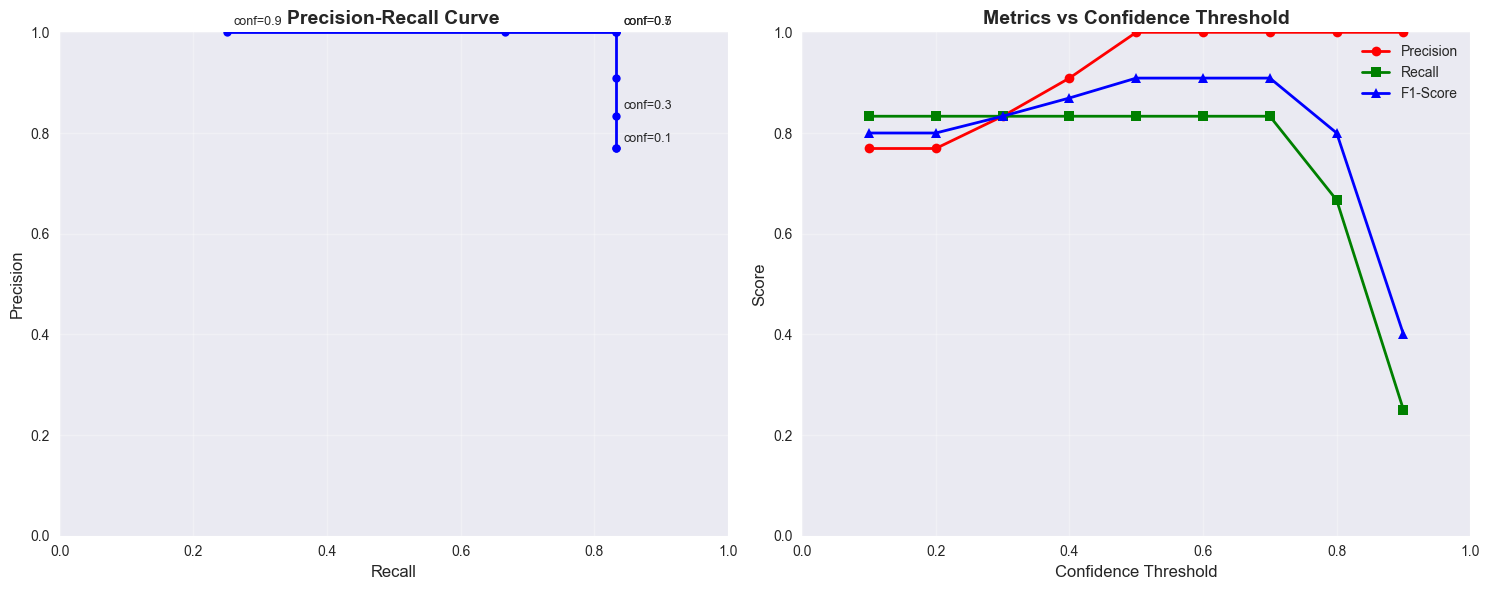

In [9]:
# Plot Precision-Recall Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Precision-Recall Curve
ax1.plot(pr_df['recall'], pr_df['precision'], 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Add annotations for key points
for i, row in pr_df.iterrows():
    if i % 2 == 0:  # Annotate every other point to avoid crowding
        ax1.annotate(f'conf={row["confidence"]:.1f}', 
                    (row['recall'], row['precision']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

# Plot 2: Precision, Recall, and F1 vs Confidence
ax2.plot(pr_df['confidence'], pr_df['precision'], 'r-o', label='Precision', linewidth=2)
ax2.plot(pr_df['confidence'], pr_df['recall'], 'g-s', label='Recall', linewidth=2)
ax2.plot(pr_df['confidence'], pr_df['f1_score'], 'b-^', label='F1-Score', linewidth=2)
ax2.set_xlabel('Confidence Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Metrics vs Confidence Threshold', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Mean Average Precision (mAP)

**mAP is the gold standard metric for object detection evaluation.**

**Key concepts:**
- **Average Precision (AP)**: Area under the Precision-Recall curve for one class
- **mAP**: Mean of AP across all classes
- **mAP@0.5**: mAP calculated with IoU threshold = 0.5
- **mAP@0.5:0.95**: mAP averaged over IoU thresholds from 0.5 to 0.95 (COCO style)

**Steps to calculate AP:**
1. Sort predictions by confidence (descending)
2. Calculate precision and recall at each confidence level
3. Compute area under the Precision-Recall curve

In [10]:
def calculate_ap(ground_truth, predictions, class_id, iou_threshold=0.5):
    """
    Calculate Average Precision for a single class.
    """
    # Collect all predictions for this class across all images
    all_predictions = []
    total_gt_objects = 0
    
    for img_id in ground_truth.keys():
        # Count ground truth objects for this class
        gt_objects = [gt for gt in ground_truth[img_id] if gt['class_id'] == class_id]
        total_gt_objects += len(gt_objects)
        
        # Collect predictions for this class
        img_predictions = predictions.get(img_id, [])
        for pred in img_predictions:
            if pred['class_id'] == class_id:
                all_predictions.append({
                    'confidence': pred['confidence'],
                    'bbox': pred['bbox'],
                    'image_id': img_id
                })
    
    if total_gt_objects == 0:
        return 0.0  # No ground truth objects for this class
    
    # Sort predictions by confidence (descending)
    all_predictions.sort(key=lambda x: x['confidence'], reverse=True)
    
    # Calculate precision and recall at each threshold
    tp_cumsum = 0
    fp_cumsum = 0
    precisions = []
    recalls = []
    
    # Track which ground truth objects have been matched
    gt_matched = {img_id: [False] * len([gt for gt in ground_truth[img_id] if gt['class_id'] == class_id]) 
                  for img_id in ground_truth.keys()}
    
    for pred in all_predictions:
        img_id = pred['image_id']
        gt_objects = [gt for gt in ground_truth[img_id] if gt['class_id'] == class_id]
        
        # Find best matching ground truth object
        best_iou = 0
        best_gt_idx = -1
        
        for gt_idx, gt in enumerate(gt_objects):
            iou = calculate_iou(pred['bbox'], gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        # Determine if this is TP or FP
        if best_iou >= iou_threshold and not gt_matched[img_id][best_gt_idx]:
            tp_cumsum += 1
            gt_matched[img_id][best_gt_idx] = True
        else:
            fp_cumsum += 1
        
        # Calculate precision and recall
        precision = tp_cumsum / (tp_cumsum + fp_cumsum)
        recall = tp_cumsum / total_gt_objects
        
        precisions.append(precision)
        recalls.append(recall)
    
    # Add point (0, 1) at the beginning if we have predictions
    if len(precisions) > 0:
        precisions = [1.0] + precisions
        recalls = [0.0] + recalls
    
    # Calculate AP using the 11-point interpolation method
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        # Find precision at recall >= t
        p_interp = 0
        for i, r in enumerate(recalls):
            if r >= t:
                p_interp = max(p_interp, precisions[i])
        ap += p_interp / 11.0
    
    return ap, precisions, recalls

# Calculate AP for each class
ap_results = {}
for class_name in classes:
    class_id = class_to_id[class_name]
    ap, precisions, recalls = calculate_ap(ground_truth, predictions, class_id, iou_threshold=0.5)
    ap_results[class_name] = {'ap': ap, 'precisions': precisions, 'recalls': recalls}
    print(f"AP for {class_name}: {ap:.3f}")

# Calculate mAP
map_score = np.mean([ap_results[cls]['ap'] for cls in classes])
print(f"\\nmAP@0.5: {map_score:.3f}")

AP for car: 1.000
AP for person: 0.818
AP for bike: 0.636
\nmAP@0.5: 0.818


ValueError: 'red-o' is not a valid format string (unrecognized character 'e')

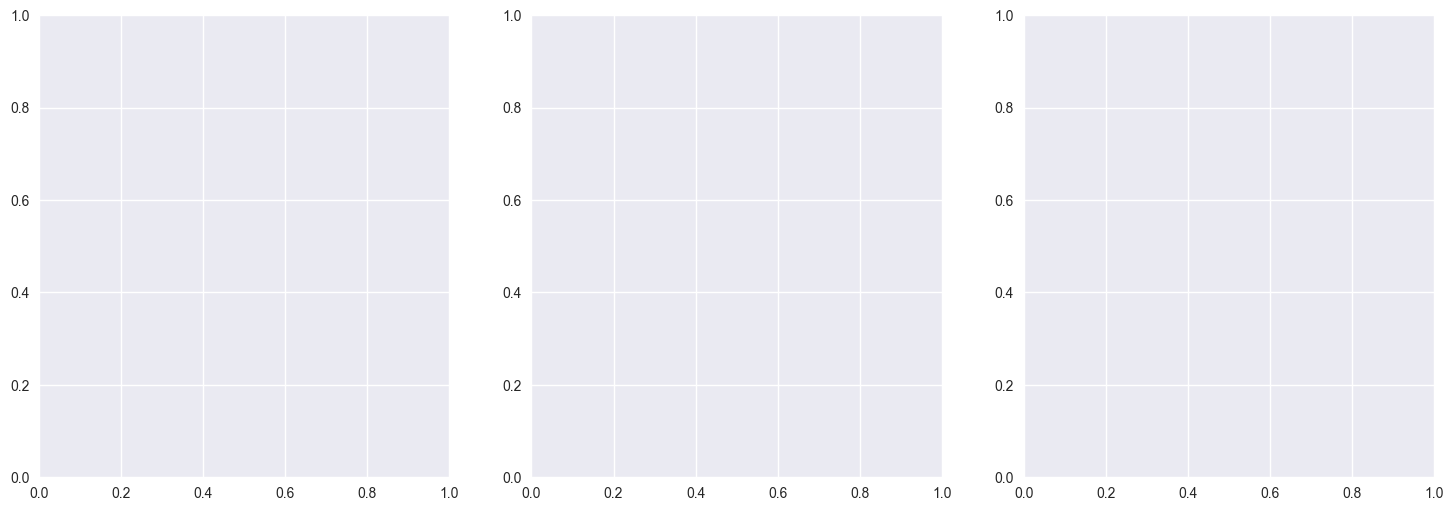

In [11]:
# Visualize Precision-Recall curves for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['red', 'green', 'blue']
for i, class_name in enumerate(classes):
    ax = axes[i]
    precisions = ap_results[class_name]['precisions']
    recalls = ap_results[class_name]['recalls']
    ap = ap_results[class_name]['ap']
    
    if len(precisions) > 0:
        ax.plot(recalls, precisions, f'{colors[i]}-o', linewidth=2, markersize=4)
        ax.fill_between(recalls, precisions, alpha=0.3, color=colors[i])
    
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{class_name.title()} - AP = {ap:.3f}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(f'Precision-Recall Curves by Class (mAP@0.5 = {map_score:.3f})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### mAP at Different IoU Thresholds

Let's see how mAP changes with different IoU thresholds and implement COCO-style mAP@0.5:0.95.

In [12]:
# Calculate mAP at different IoU thresholds
iou_thresholds = np.arange(0.5, 1.0, 0.05)
map_at_ious = []

print("mAP at Different IoU Thresholds:")
print("=" * 40)
print(f"{'IoU Threshold':<15} {'mAP':<10}")
print("-" * 40)

for iou_thresh in iou_thresholds:
    class_aps = []
    for class_name in classes:
        class_id = class_to_id[class_name]
        ap, _, _ = calculate_ap(ground_truth, predictions, class_id, iou_threshold=iou_thresh)
        class_aps.append(ap)
    
    map_score = np.mean(class_aps)
    map_at_ious.append(map_score)
    print(f"{iou_thresh:<15.2f} {map_score:<10.3f}")

# Calculate COCO-style mAP@0.5:0.95
coco_map = np.mean(map_at_ious)
print(f"\\nmAP@0.5:0.95 (COCO style): {coco_map:.3f}")
print(f"mAP@0.5: {map_at_ious[0]:.3f}")
print(f"mAP@0.75: {map_at_ious[5]:.3f}")

mAP at Different IoU Thresholds:
IoU Threshold   mAP       
----------------------------------------
0.50            0.818     
0.55            0.818     
0.60            0.705     
0.65            0.677     
0.70            0.545     
0.75            0.182     
0.80            0.182     
0.85            0.121     
0.90            0.091     
0.95            0.091     
\nmAP@0.5:0.95 (COCO style): 0.423
mAP@0.5: 0.818
mAP@0.75: 0.182


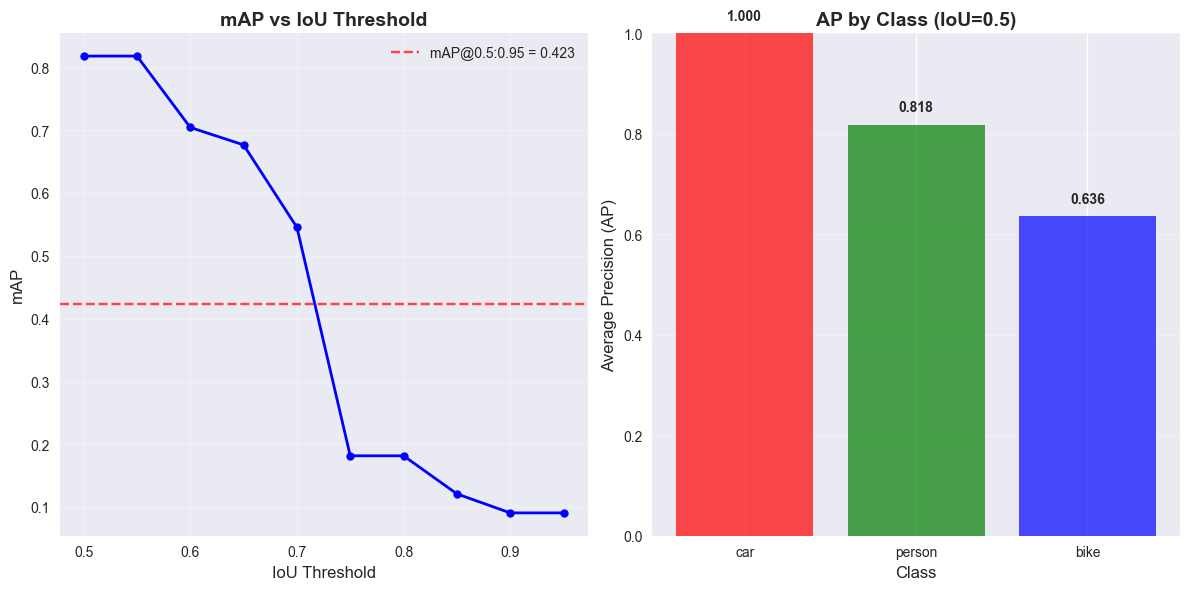

In [13]:
# Plot mAP vs IoU threshold
plt.figure(figsize=(12, 6))

# Plot mAP vs IoU threshold
plt.subplot(1, 2, 1)
plt.plot(iou_thresholds, map_at_ious, 'b-o', linewidth=2, markersize=6)
plt.xlabel('IoU Threshold', fontsize=12)
plt.ylabel('mAP', fontsize=12)
plt.title('mAP vs IoU Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=coco_map, color='r', linestyle='--', alpha=0.7, label=f'mAP@0.5:0.95 = {coco_map:.3f}')
plt.legend()

# Bar plot of AP by class at IoU=0.5
plt.subplot(1, 2, 2)
class_names = list(classes)
ap_values = [ap_results[cls]['ap'] for cls in class_names]
bars = plt.bar(class_names, ap_values, color=['red', 'green', 'blue'], alpha=0.7)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Average Precision (AP)', fontsize=12)
plt.title('AP by Class (IoU=0.5)', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, ap_val in zip(bars, ap_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{ap_val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Class-wise vs Class-agnostic Evaluation

**Two different evaluation approaches:**

1. **Class-wise (what we've been doing)**: Predictions must match both bounding box location AND class
2. **Class-agnostic**: Only bounding box location matters, ignore class predictions

Class-agnostic evaluation helps understand if the model can detect "objects" regardless of classification accuracy.

In [14]:
def calculate_class_agnostic_metrics(ground_truth, predictions, iou_threshold=0.5, confidence_threshold=0.5):
    """
    Calculate class-agnostic metrics (ignore class predictions)
    """
    tp = 0
    fp = 0
    total_gt = 0
    
    for img_id in ground_truth.keys():
        gt_boxes = ground_truth[img_id]
        pred_boxes = [p for p in predictions.get(img_id, []) if p['confidence'] >= confidence_threshold]
        
        total_gt += len(gt_boxes)
        
        # Track which ground truth boxes have been matched
        gt_matched = [False] * len(gt_boxes)
        
        # Process each prediction (ignore class)
        for pred in pred_boxes:
            best_iou = 0
            best_gt_idx = -1
            
            # Find best matching ground truth box (any class)
            for gt_idx, gt in enumerate(gt_boxes):
                iou = calculate_iou(pred['bbox'], gt['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
            
            # Determine if this is TP or FP (class-agnostic)
            if best_iou >= iou_threshold and not gt_matched[best_gt_idx]:
                tp += 1
                gt_matched[best_gt_idx] = True
            else:
                fp += 1
    
    fn = total_gt - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'TP': tp, 'FP': fp, 'FN': fn, 'precision': precision, 'recall': recall, 'f1': f1}

# Compare class-wise vs class-agnostic evaluation
print("Class-wise vs Class-agnostic Comparison:")
print("=" * 50)

# Class-wise evaluation (what we calculated before)
class_wise_results = evaluate_predictions(ground_truth, predictions, confidence_threshold=0.5)
class_wise_tp = class_wise_results['overall']['TP']
class_wise_fp = class_wise_results['overall']['FP']
class_wise_fn = class_wise_results['overall']['FN']
class_wise_precision = class_wise_tp / (class_wise_tp + class_wise_fp) if (class_wise_tp + class_wise_fp) > 0 else 0
class_wise_recall = class_wise_tp / (class_wise_tp + class_wise_fn) if (class_wise_tp + class_wise_fn) > 0 else 0
class_wise_f1 = 2 * (class_wise_precision * class_wise_recall) / (class_wise_precision + class_wise_recall) if (class_wise_precision + class_wise_recall) > 0 else 0

# Class-agnostic evaluation
class_agnostic_results = calculate_class_agnostic_metrics(ground_truth, predictions, confidence_threshold=0.5)

print(f"{'Metric':<15} {'Class-wise':<12} {'Class-agnostic':<15} {'Difference':<12}")
print("-" * 55)
print(f"{'Precision':<15} {class_wise_precision:<12.3f} {class_agnostic_results['precision']:<15.3f} {class_agnostic_results['precision'] - class_wise_precision:<12.3f}")
print(f"{'Recall':<15} {class_wise_recall:<12.3f} {class_agnostic_results['recall']:<15.3f} {class_agnostic_results['recall'] - class_wise_recall:<12.3f}")
print(f"{'F1-Score':<15} {class_wise_f1:<12.3f} {class_agnostic_results['f1']:<15.3f} {class_agnostic_results['f1'] - class_wise_f1:<12.3f}")

print(f"\\nDetailed Counts:")
print(f"Class-wise    - TP: {class_wise_tp}, FP: {class_wise_fp}, FN: {class_wise_fn}")
print(f"Class-agnostic - TP: {class_agnostic_results['TP']}, FP: {class_agnostic_results['FP']}, FN: {class_agnostic_results['FN']}")

Class-wise vs Class-agnostic Comparison:
Metric          Class-wise   Class-agnostic  Difference  
-------------------------------------------------------
Precision       1.000        1.000           0.000       
Recall          0.833        0.833           0.000       
F1-Score        0.909        0.909           0.000       
\nDetailed Counts:
Class-wise    - TP: 10, FP: 0, FN: 2
Class-agnostic - TP: 10, FP: 0, FN: 2


## 7. Summary and Key Takeaways

Let's create a comprehensive summary with visual explanations of all the concepts we've covered.

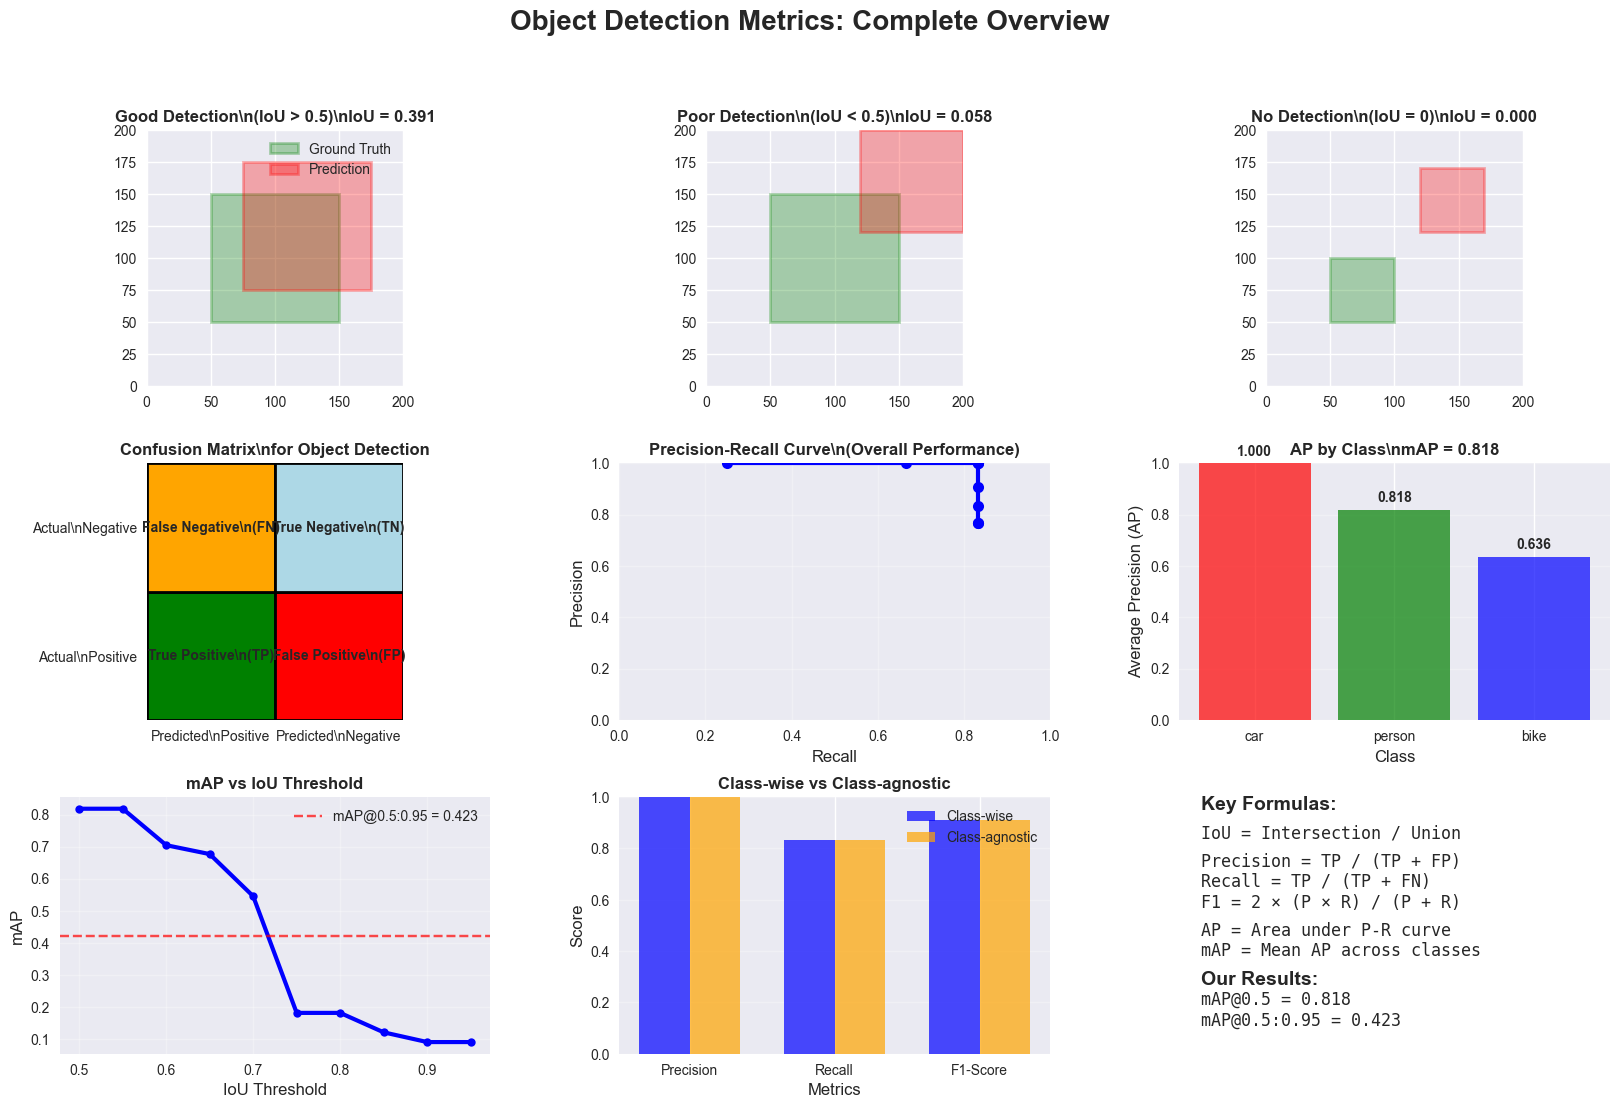

In [15]:
# Create a comprehensive summary visualization
fig = plt.figure(figsize=(20, 12))

# Create a 3x3 grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. IoU Examples (top row)
for i, (title, boxes, expected_iou) in enumerate([
    ("Good Detection\\n(IoU > 0.5)", ([50, 50, 150, 150], [75, 75, 175, 175]), 0.368),
    ("Poor Detection\\n(IoU < 0.5)", ([50, 50, 150, 150], [120, 120, 200, 200]), 0.111),
    ("No Detection\\n(IoU = 0)", ([50, 50, 100, 100], [120, 120, 170, 170]), 0.0)
]):
    ax = fig.add_subplot(gs[0, i])
    
    # Draw boxes
    rect1 = Rectangle((boxes[0][0], boxes[0][1]), boxes[0][2]-boxes[0][0], boxes[0][3]-boxes[0][1], 
                     linewidth=2, edgecolor='green', facecolor='green', alpha=0.3, label='Ground Truth')
    rect2 = Rectangle((boxes[1][0], boxes[1][1]), boxes[1][2]-boxes[1][0], boxes[1][3]-boxes[1][1], 
                     linewidth=2, edgecolor='red', facecolor='red', alpha=0.3, label='Prediction')
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    
    actual_iou = calculate_iou(boxes[0], boxes[1])
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\\nIoU = {actual_iou:.3f}', fontsize=12, fontweight='bold')
    if i == 0:
        ax.legend(loc='upper right', fontsize=10)

# 2. Precision-Recall explanation (middle left)
ax = fig.add_subplot(gs[1, 0])
confusion_data = {
    'Predicted': ['Positive', 'Positive', 'Negative', 'Negative'],
    'Actual': ['Positive', 'Negative', 'Positive', 'Negative'],
    'Label': ['True Positive\\n(TP)', 'False Positive\\n(FP)', 'False Negative\\n(FN)', 'True Negative\\n(TN)'],
    'Color': ['green', 'red', 'orange', 'lightblue']
}

for i, (pred, actual, label, color) in enumerate(zip(confusion_data['Predicted'], confusion_data['Actual'], confusion_data['Label'], confusion_data['Color'])):
    x, y = i % 2, i // 2
    rect = Rectangle((x, y), 1, 1, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 0.5, y + 0.5, label, ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect('equal')
ax.set_title('Confusion Matrix\\nfor Object Detection', fontsize=12, fontweight='bold')
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Predicted\\nPositive', 'Predicted\\nNegative'])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Actual\\nPositive', 'Actual\\nNegative'])

# 3. Precision-Recall curve (middle center)
ax = fig.add_subplot(gs[1, 1])
ax.plot(pr_df['recall'], pr_df['precision'], 'b-o', linewidth=3, markersize=8)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve\\n(Overall Performance)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 4. mAP explanation (middle right)
ax = fig.add_subplot(gs[1, 2])
class_names = list(classes)
ap_values = [ap_results[cls]['ap'] for cls in class_names]
bars = ax.bar(class_names, ap_values, color=['red', 'green', 'blue'], alpha=0.7)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Average Precision (AP)', fontsize=12)
ax.set_title(f'AP by Class\\nmAP = {np.mean(ap_values):.3f}', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

for bar, ap_val in zip(bars, ap_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{ap_val:.3f}', ha='center', va='bottom', fontweight='bold')

# 5. mAP vs IoU threshold (bottom left)
ax = fig.add_subplot(gs[2, 0])
ax.plot(iou_thresholds, map_at_ious, 'b-o', linewidth=3, markersize=6)
ax.set_xlabel('IoU Threshold', fontsize=12)
ax.set_ylabel('mAP', fontsize=12)
ax.set_title('mAP vs IoU Threshold', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=coco_map, color='r', linestyle='--', alpha=0.7, label=f'mAP@0.5:0.95 = {coco_map:.3f}')
ax.legend()

# 6. Class-wise vs Class-agnostic comparison (bottom center)
ax = fig.add_subplot(gs[2, 1])
metrics = ['Precision', 'Recall', 'F1-Score']
class_wise_vals = [class_wise_precision, class_wise_recall, class_wise_f1]
class_agnostic_vals = [class_agnostic_results['precision'], class_agnostic_results['recall'], class_agnostic_results['f1']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, class_wise_vals, width, label='Class-wise', alpha=0.7, color='blue')
bars2 = ax.bar(x + width/2, class_agnostic_vals, width, label='Class-agnostic', alpha=0.7, color='orange')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Class-wise vs Class-agnostic', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# 7. Key formulas (bottom right)
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
formulas = [
    "Key Formulas:",
    "",
    "IoU = Intersection / Union",
    "",
    "Precision = TP / (TP + FP)",
    "Recall = TP / (TP + FN)",
    "F1 = 2 × (P × R) / (P + R)",
    "",
    "AP = Area under P-R curve",
    "mAP = Mean AP across classes",
    "",
    f"Our Results:",
    f"mAP@0.5 = {map_at_ious[0]:.3f}",
    f"mAP@0.5:0.95 = {coco_map:.3f}"
]

y_pos = 0.95
for formula in formulas:
    if formula.startswith("Key Formulas") or formula.startswith("Our Results"):
        ax.text(0.05, y_pos, formula, fontsize=14, fontweight='bold', transform=ax.transAxes)
    elif formula == "":
        y_pos -= 0.03
        continue
    else:
        ax.text(0.05, y_pos, formula, fontsize=12, transform=ax.transAxes, family='monospace')
    y_pos -= 0.08

plt.suptitle('Object Detection Metrics: Complete Overview', fontsize=20, fontweight='bold', y=0.98)
plt.show()

## 8. Conclusion and Best Practices

### What We've Learned

1. **IoU** is the foundation metric - it measures how well predicted boxes overlap with ground truth
2. **Precision and Recall** form the basis for all other metrics in object detection
3. **mAP** is the gold standard - it's the area under the Precision-Recall curve, averaged across classes
4. **Different IoU thresholds** test different levels of localization accuracy
5. **Class-agnostic evaluation** helps separate localization performance from classification performance

### Key Metrics to Remember

- **mAP@0.5**: Standard benchmark, relatively lenient
- **mAP@0.5:0.95**: COCO standard, more comprehensive and strict
- **Class-wise mAP**: Most common, penalizes wrong classifications
- **Class-agnostic mAP**: Focuses purely on localization ability

### Best Practices for Model Evaluation

1. **Always report both mAP@0.5 and mAP@0.5:0.95**
2. **Analyze per-class performance** to identify weak classes
3. **Consider class-agnostic metrics** to understand localization vs classification errors
4. **Visualize precision-recall curves** to understand model behavior
5. **Test at multiple confidence thresholds** to find optimal operating points

### Next Steps

Now you understand how to evaluate object detection models! You can:
- Apply these metrics to your own detection models
- Compare different model architectures fairly
- Understand published paper results
- Debug model performance issues by analyzing per-class metrics